**Imports**

In [1]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tensorflow.keras.models import load_model
import os
import shutil
import zipfile

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Configuaration**

In [7]:
# 2. CONFIGURATION
# ================================================================
MODEL_PATH_YOLO = "/content/drive/MyDrive/Thesis/Models/yolov8_braille.pt"
IMAGE_PATH      = "/content/drive/MyDrive/Thesis/TestImages/95_2_libs.jpg"
OUTPUT_DIR      = "/content/CroppedCells"
CNN_MODEL_PATH  = "/content/drive/MyDrive/Thesis/Models/CNN.h5"

# Detection thresholds
CONFIDENCE_THRESHOLD_DETECT = 0.10
IOU_NMS_THRESHOLD           = 0.10
DUPLICATE_IOU               = 0.40

# Grid snapping & fusion parameters
TOLERANCE_BASE      = 0.45
TOLERANCE_MAX       = 0.75
HIGH_CONF_ORPHAN    = 0.60
GAP_FILL_X_MULT     = 1.5
GAP_FILL_Y_MULT     = 1.2

# Target CNN input size
TARGET_H, TARGET_W = 50, 50

# Text reading order & spacing
READING_ORDER = "LTR"
USE_GAP_SPACING = True
WORD_GAP_MULTIPLIER = 1.6

# Recognition threshold
MIN_CLS_CONF = 0.2

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration done. Output directory is:", OUTPUT_DIR)

Configuration done. Output directory is: /content/CroppedCells


In [8]:
# ================================================================
# 3. ARABIC MAPPING & DIACRITICS
# ================================================================
def map_to_arabic(class_index):
    arabic_mapping = {
        0: "ُ", 1: "ٌ", 2: "َ", 3: "ً", 4: "ِ", 5: "ٍ", 6: "ّ", 7: "ْ",
        8: "ء", 9: "ا", 10: "آ", 11: "أ", 12: "إ", 13: "ب", 14: "ة", 15: "ت",
        16: "ث", 17: "ج", 18: "ح", 19: "خ", 20: "د", 21: "ذ", 22: "ر", 23: "ز",
        24: "س", 25: "ش", 26: "ص", 27: "ض", 28: "ط", 29: "ظ", 30: "ع", 31: "غ",
        32: "ف", 33: "ق", 34: "ك", 35: "ل", 36: "لا", 37: "م", 38: "ن", 39: "ه",
        40: "و", 41: "ؤ", 42: "ى", 43: "ي", 44: "ئ"
    }
    return arabic_mapping.get(class_index, "")

DIACRITIC_SET = set(["ُ","ٌ","َ","ً","ِ","ٍ","ْ","ّ"])
print("Arabic mapping functions ready.")


Arabic mapping functions ready.


In [9]:
# ================== HELPER FUNCTIONS ==================
def iou_xyxy(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter + 1e-9)

def deduplicate_boxes(boxes, confs, clss, dup_iou=0.9):
    if len(boxes) == 0:
        return boxes, confs, clss
    order = np.argsort(-confs)
    boxes, confs, clss = boxes[order], confs[order], clss[order]
    kept_b, kept_c, kept_k = [], [], []
    for i, b in enumerate(boxes):
        if all(iou_xyxy(b, kb) < dup_iou for kb in kept_b):
            kept_b.append(b); kept_c.append(confs[i]); kept_k.append(clss[i])
    return np.array(kept_b), np.array(kept_c), np.array(kept_k)

def preprocess_cell(img_bgr, box):
    x1, y1, x2, y2 = [int(v) for v in box]
    crop = img_bgr[max(0, y1):y2, max(0, x1):x2]

    if crop.size == 0:
        return None

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # Centering & padding to square, then resize
    h, w = gray.shape
    side = max(h, w)
    square = np.full((side, side), 255, dtype=np.uint8)
    y_offset = (side - h) // 2
    x_offset = (side - w) // 2
    square[y_offset:y_offset+h, x_offset:x_offset+w] = gray

    resized = cv2.resize(square, (TARGET_W, TARGET_H), interpolation=cv2.INTER_AREA)
    normalized = resized.astype("float32") / 255.0
    final = normalized[..., None]  # (50,50,1)
    return final
def _cluster_1d(values, bandwidth):
    """Simple 1D agglomerative clustering with running-mean linkage. Returns sorted cluster means."""
    if len(values) == 0:
        return []
    vals = sorted(values)
    clusters = []
    current = [vals[0]]
    for v in vals[1:]:
        if abs(v - np.mean(current)) <= bandwidth:
            current.append(v)
        else:
            clusters.append(np.mean(current))
            current = [v]
    clusters.append(np.mean(current))
    return sorted(clusters)

# ================== GRID-SNAPPING (ADAPTIVE + FUSION) ==================
def snap_to_braille_grid_adaptive(boxes, confs, tolerance_base=0.45, tolerance_max=0.75,
                                  high_conf_orphan=0.6, gap_x_mult=1.5, gap_y_mult=1.2):
    """
    Build a consistent grid from YOLO boxes with:
      - adaptive tolerance (based on spread of box sizes)
      - gap filling using unused YOLO candidates
      - optional template augmentation from high-confidence orphans

    Returns:
        grid: list[list[box or None]] aligned to a global column template
        row_anchors: list[float]
        col_template: list[float]
        used_indices: set[int]
        extras_per_row: dict[row_index -> list[box]]  # orphan boxes within row band not used
    """
    if boxes is None or len(boxes) == 0:
        return [], [], [], set(), {}

    centers = np.column_stack(((boxes[:,0] + boxes[:,2]) * 0.5,
                               (boxes[:,1] + boxes[:,3]) * 0.5))
    widths  = (boxes[:,2] - boxes[:,0]).astype(float)
    heights = (boxes[:,3] - boxes[:,1]).astype(float)

    med_w, med_h = np.median(widths), np.median(heights)
    if med_w <= 0 or med_h <= 0:
        return [], [], [], set(), {}

    # --- Adaptive tolerance from variability (robust: MAD over median) ---
    def _robust_spread(x):
        med = np.median(x)
        return np.median(np.abs(x - med)) / (med + 1e-9)

    spread_w = _robust_spread(widths)
    spread_h = _robust_spread(heights)
    adapt = max(spread_w, spread_h)
    tol = np.clip(tolerance_base * (1.0 + adapt), 0.30, tolerance_max)

    row_band = max(2.0, tol * med_h)
    col_band = max(2.0, tol * med_w)

    # ---- Row anchors (cluster Y) ----
    row_anchors = _cluster_1d(list(centers[:,1]), row_band)

    # Collect per-row indices
    per_row_inds = []
    for ry in row_anchors:
        r_inds = [i for i, c in enumerate(centers) if abs(c[1] - ry) <= row_band]
        per_row_inds.append(r_inds)

    # ---- Per-row column clusters & initial template from densest row ----
    per_row_cols = []
    for r_inds in per_row_inds:
        if not r_inds:
            per_row_cols.append([])
            continue
        x_vals = [centers[i,0] for i in r_inds]
        col_anchors = _cluster_1d(x_vals, col_band)
        per_row_cols.append(col_anchors)

    if per_row_cols:
        max_cols_row = int(np.argmax([len(cols) for cols in per_row_cols]))
        col_template = per_row_cols[max_cols_row].copy()
    else:
        col_template = []

    # ---- Optional: augment template using high-confidence orphans ----
    # If a YOLO box is within some row but far from all template cols, and has high conf → add its cx
    used_indices = set()
    if len(col_template) >= 1:
        candidate_cx = []
        for r, r_inds in enumerate(per_row_inds):
            for i in r_inds:
                cx, cy = centers[i]
                if len(col_template) == 0:
                    continue
                dx = np.min(np.abs(np.array(col_template) - cx)) if col_template else 1e9
                if dx > 1.5 * col_band and confs[i] >= high_conf_orphan:
                    candidate_cx.append(cx)
        # Merge candidates that are sufficiently apart
        candidate_cx = _cluster_1d(candidate_cx, col_band)
        if candidate_cx:
            col_template = sorted(list(col_template) + list(candidate_cx))

    # ---- Assign boxes to nearest template column per row ----
    grid = []
    extras_per_row = {}
    for r, ry in enumerate(row_anchors):
        r_inds = per_row_inds[r]
        row_list = []
        row_extras = []
        if not r_inds or not col_template:
            # rows with no detections or no template
            row_list = [None for _ in range(len(col_template))]
            extras_per_row[r] = row_extras
            grid.append(row_list)
            continue
        r_centers = centers[r_inds]
        r_boxes   = boxes[r_inds]

        # For each template column, pick best candidate within bands
        for cx_t in col_template:
            # plausible candidates by y-closeness
            y_ok = np.abs(r_centers[:,1] - ry) <= row_band
            if not np.any(y_ok):
                row_list.append(None)
                continue
            # distance in x to the template column
            x_dists = np.abs(r_centers[:,0] - cx_t)
            idx_candidates = np.where(y_ok & (x_dists <= 1.2 * col_band))[0]
            if idx_candidates.size == 0:
                row_list.append(None)
                continue
            # choose the one with smallest x distance (break ties by higher conf)
            best_local = idx_candidates[np.argmin(x_dists[idx_candidates])]
            chosen_idx_global = r_inds[int(best_local)]
            chosen_box = boxes[chosen_idx_global]
            row_list.append(chosen_box)
            used_indices.add(chosen_idx_global)

        grid.append(row_list)

        # Collect orphans inside the row band not used (to optionally include in recognition)
        for local_j, gi in enumerate(r_inds):
            if gi not in used_indices and abs(centers[gi,1] - ry) <= row_band:
                row_extras.append(boxes[gi])
        extras_per_row[r] = row_extras

    # ---- Gap filling: try to fill Nones from unused YOLO boxes near expected centers ----
    unused = set(range(len(boxes))) - used_indices
    for r, ry in enumerate(row_anchors):
        if not col_template:
            continue
        for c, cx_t in enumerate(col_template):
            if grid[r][c] is not None:
                continue
            # find nearest unused candidate near (cx_t, ry)
            best_idx = -1
            best_score = 1e9
            for i in list(unused):
                cx, cy = centers[i]
                if abs(cy - ry) <= gap_y_mult * row_band and abs(cx - cx_t) <= gap_x_mult * col_band:
                    # score by elliptical distance in (x,y)
                    dx = abs(cx - cx_t) / (col_band + 1e-9)
                    dy = abs(cy - ry) / (row_band + 1e-9)
                    score = dx + dy - 0.25 * confs[i]  # prefer higher conf
                    if score < best_score:
                        best_score = score
                        best_idx = i
            if best_idx >= 0:
                grid[r][c] = boxes[best_idx]
                used_indices.add(best_idx)
                if best_idx in unused:
                    unused.remove(best_idx)

    # Update extras after gap filling (remove any newly used)
    for r in extras_per_row:
        new_list = []
        for b in extras_per_row[r]:
            # find its index in boxes
            # (approx match by IoU > 0.9)
            matched = False
            for i in used_indices:
                if i < len(boxes) and iou_xyxy(boxes[i], b) > 0.9:
                    matched = True
                    break
            if not matched:
                new_list.append(b)
        extras_per_row[r] = new_list

    return grid, row_anchors, col_template, used_indices, extras_per_row

In [10]:
# 6. LOAD MODELS & IMAGE
# ================================================================
yolo = YOLO(MODEL_PATH_YOLO)
cnn  = load_model(CNN_MODEL_PATH, compile=False)

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image at {IMAGE_PATH}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print("Models loaded and image read successfully.")



Models loaded and image read successfully.


[YOLO] Candidate boxes: 15


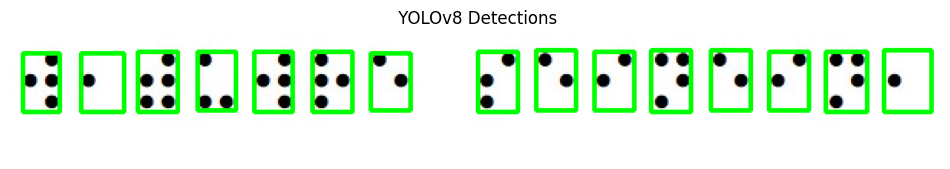

[Grid] Rows: 1, Template Columns: 15


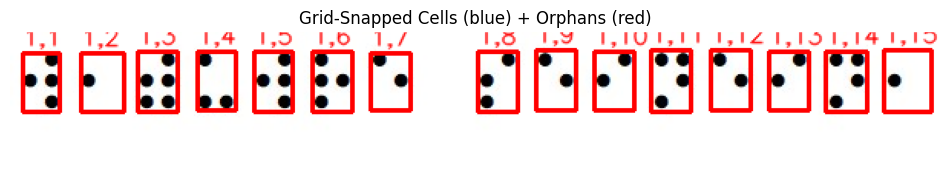

In [11]:
# ================== DETECTION (LOOSE) ==================
res = yolo.predict(
    IMAGE_PATH,
    conf=CONFIDENCE_THRESHOLD_DETECT,  # loose to get candidates
    iou=IOU_NMS_THRESHOLD,
    verbose=False
)[0]
b = res.boxes

boxes = b.xyxy.cpu().numpy() if b is not None else np.empty((0,4))
confs = b.conf.cpu().numpy() if b is not None else np.empty((0,))
clss  = b.cls.cpu().numpy().astype(int) if b is not None else np.empty((0,), dtype=int)

# Light dedupe before grid snapping
boxes, confs, clss = deduplicate_boxes(boxes, confs, clss, DUPLICATE_IOU)

print(f"[YOLO] Candidate boxes: {len(boxes)}")

# Visualize raw detections
img_vis_raw = img_rgb.copy()
for box in boxes:
    x1, y1, x2, y2 = [int(v) for v in box]
    cv2.rectangle(img_vis_raw, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(img_vis_raw); plt.axis('off'); plt.title(" YOLOv8 Detections")
plt.show()

# ================== GRID SNAPPING (ADAPTIVE + FUSION) ==================
(grid,
 row_anchors,
 col_template,
 used_indices,
 extras_per_row) = snap_to_braille_grid_adaptive(
    boxes,
    confs,
    tolerance_base=TOLERANCE_BASE,
    tolerance_max=TOLERANCE_MAX,
    high_conf_orphan=HIGH_CONF_ORPHAN,
    gap_x_mult=GAP_FILL_X_MULT,
    gap_y_mult=GAP_FILL_Y_MULT,
)

num_rows = len(grid)
num_cols = len(col_template) if len(col_template) else 0
print(f"[Grid] Rows: {num_rows}, Template Columns: {num_cols}")

# Visualize snapped grid (+ extras as dotted boxes)
img_vis_grid = img_rgb.copy()
for r, row in enumerate(grid):
    for c, box in enumerate(row):
        if box is None:
            continue
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(img_vis_grid, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_vis_grid, f"{r+1},{c+1}", (x1, max(0, y1-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1, cv2.LINE_AA)

# Draw extras (orphans) as dashed rectangles
for r, extras in extras_per_row.items():
    for box in extras:
        x1, y1, x2, y2 = [int(v) for v in box]
        # draw dashed by alternating pixels (simulate with thin rectangle + small circles)
        cv2.rectangle(img_vis_grid, (x1, y1), (x2, y2), (0, 0, 255), 1)
        cv2.circle(img_vis_grid, (x1, y1), 2, (0,0,255), -1)
        cv2.circle(img_vis_grid, (x2, y2), 2, (0,0,255), -1)

plt.figure(figsize=(12, 8))
plt.imshow(img_vis_grid); plt.axis('off'); plt.title("Grid-Snapped Cells (blue) + Orphans (red)")
plt.show()

In [12]:
# ================== CROP CELLS, SAVE & ZIP ==================
CROPPED_DIR = OUTPUT_DIR
ZIP_PATH = "/content/CroppedCells.zip"
os.makedirs(CROPPED_DIR, exist_ok=True)

cropped_count = 0
for r, row in enumerate(grid):
    for c, box in enumerate(row):
        if box is None:
            continue
        cell_img = preprocess_cell(img_bgr, box)
        if cell_img is not None:
            out_path = os.path.join(CROPPED_DIR, f"cell_r{r:02d}_c{c:02d}.jpg")
            cv2.imwrite(out_path, (cell_img.squeeze() * 255).astype(np.uint8))
            cropped_count += 1
print(f"Saved {cropped_count} cropped cells to {CROPPED_DIR}")

# Zip folder
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)
shutil.make_archive("/content/CroppedCells", 'zip', CROPPED_DIR)
print(f"Zipped folder to {ZIP_PATH}")

Saved 15 cropped cells to /content/CroppedCells
Zipped folder to /content/CroppedCells.zip


Recognition done.
Constructed Arabic Sentence
ويطكورِ سِينِينَ


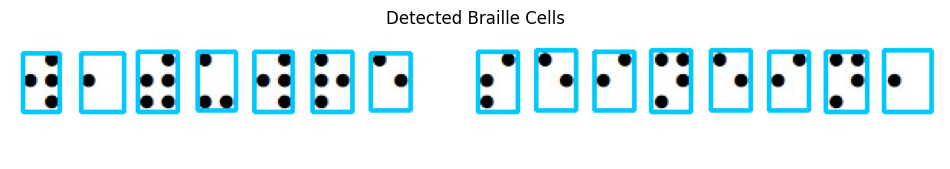

In [13]:
# ================== RECOGNITION ==================
def _box_center_x(box):
    return 0.5 * (box[0] + box[2])

def _box_width(box):
    return (box[2] - box[0])

def recognize_grid_with_extras(grid, extras_per_row, reading_order="LTR", use_gap_spacing=True, gap_multiplier=1.6):
    """
    Recognize Braille cells from snapped grid **plus orphan extras**.
    We form a single ordered sequence per row by merging:
        - grid-aligned boxes
        - extras (orphans) within the row band
    and then apply the same CNN+diacritic logic.
    """
    recognized_lines = []

    for r, row in enumerate(grid):
        entries = []
        # add grid boxes
        for c, box in enumerate(row):
            if box is None: continue
            entries.append((c, box, _box_center_x(box), _box_width(box)))
        # add extras with a synthetic column index after the last template col
        extra_boxes = extras_per_row.get(r, []) if extras_per_row else []
        for box in extra_boxes:
            entries.append((len(row)+1, box, _box_center_x(box), _box_width(box)))

        if not entries:
            recognized_lines.append("")
            continue

        # Sort by x center; flip for RTL
        entries.sort(key=lambda t: t[2])
        if reading_order.upper() == "RTL":
            entries = list(reversed(entries))

        widths = [w for (_, _, __, w) in entries]
        med_w = float(np.median(widths)) if widths else 1.0
        gap_thr = gap_multiplier * med_w

        line_parts = []
        temp_shadda = ""
        prev_x = None

        for idx, (c, box, cx, w) in enumerate(entries):
            cell_img = preprocess_cell(img_bgr, box)
            if cell_img is None:
                prev_x = cx
                continue

            inp = np.expand_dims(cell_img, axis=0)
            probs = cnn.predict(inp, verbose=0)[0]
            cls_idx = int(np.argmax(probs))
            cls_conf = float(probs[cls_idx])
            label_raw = map_to_arabic(cls_idx) if cls_conf >= MIN_CLS_CONF else "?"

            # Optional word gap insertion (based on x-gap between centers)
            if use_gap_spacing and prev_x is not None:
                gap = abs(cx - prev_x)
                if gap > gap_thr and (len(line_parts) > 0) and line_parts[-1] != " ":
                    line_parts.append(" ")

            # Diacritic handling
            if label_raw in DIACRITIC_SET:
                if label_raw == "ّ":
                    temp_shadda = label_raw
                else:
                    if line_parts and line_parts[-1] != " ":
                        line_parts[-1] += label_raw
                    else:
                        line_parts.append(label_raw)
            else:
                if temp_shadda:
                    line_parts.append(temp_shadda + label_raw)
                    temp_shadda = ""
                else:
                    line_parts.append(label_raw)

            prev_x = cx

        recognized_lines.append("".join(line_parts).strip())

    return recognized_lines

recognized_lines = recognize_grid_with_extras(
    grid,
    extras_per_row,
    reading_order=READING_ORDER,
    use_gap_spacing=USE_GAP_SPACING,
    gap_multiplier=WORD_GAP_MULTIPLIER,
)

print("Recognition done.")
print("Constructed Arabic Sentence")
for line in recognized_lines:
    print(line)

# ================== OPTIONAL: DRAW FINAL ANNOTATION ==================
annotated = img_rgb.copy()
for r, row in enumerate(grid):
    for c, box in enumerate(row):
        if box is None:
            continue
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(annotated); plt.axis('off'); plt.title("Detected Braille Cells")
plt.show()
